In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [3]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [4]:
blob_center = np.array([[0.2, 2.3], [-1.5, 2.3], [-2.8, 1.8], [-2.8, 2.8], [-2.8, 1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y = make_blobs(n_samples=2000, centers=blob_center, cluster_std=blob_std, random_state=101)

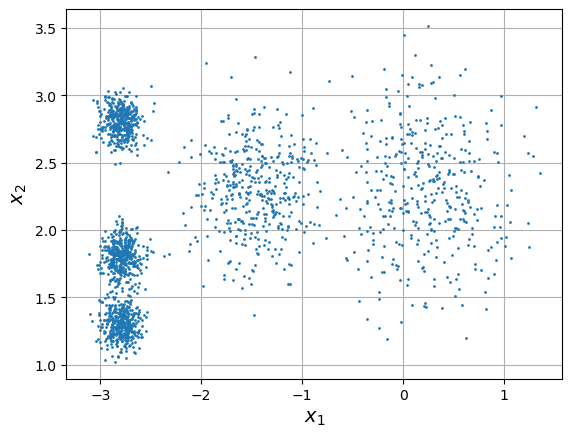

In [6]:
def plt_clusters(X, y=None):
    plt.scatter(X[:,0], X[:,1], c=y, s=1)
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')

plt_clusters(X)
plt.gca().set_axisbelow(True)
plt.grid()
plt.show()

In [ ]:
n_clusters = 5
max_iters = 100

rng = np.random.default_rng(seed=42)

self.cluster_centers_ = X[rng.choice(len(X), n_clusters, replace=False)]

for _ in range(max_iters):
    distances = np.linalg.norm(X[:, None] - self.cluster_centers_, axis=2)
    labels = np.argmin(distances, axis=1)
    
    new_centroids = np.array([X[labels == k].mean(axis=0) for k in range(n_clusters)])
    
    converged = np.allclose(new_centroids, self.cluster_centers_)
    self.cluster_centers_ = new_centroids
    
    if converged:
        break

self.cluster_centers_

array([[-1.44302069,  2.29563944],
       [-2.79515956,  1.30093499],
       [-2.77950906,  1.8077965 ],
       [ 0.23833329,  2.29103643],
       [-2.79246994,  2.79993707]])

In [37]:
from sklearn.base import BaseEstimator

In [ ]:
class MyKmeans(BaseEstimator):
    def __init__(self, n_clusters=3, max_iter=100, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter=max_iter
        self.random_state = random_state
    
    def fit(self, X, y=None):
        rng = np.random.default_rng(seed=self.random_state)
        self.cluster_centers_ = X[rng.choice(len(X), self.n_clusters, replace=False)]

        for _ in range(self.max_iter):
            distances = np.linalg.norm(X[:, None] - self.cluster_centers_, axis=2)
            labels = np.argmin(distances, axis=1)
            
            new_centroids = np.array(
                [X[labels == k].mean(axis=0)
                 for k in range(n_clusters)])
            
            converged = np.allclose(new_centroids, self.cluster_centers_)
            self.cluster_centers_ = new_centroids
    
            if converged:
                break
        
        distances = np.linalg.norm(X[:, None] - self.cluster_centers_, axis=2)
        labels = np.argmin(distances, axis=1)
        
        return self
    
    def predict(self, X):
        distances = np.linalg.norm(X[:,None] - self.cluster_centers_, axis=2)
        return np.argmin(distances, axis=1)

In [ ]:
model = MyKmeans(n_clusters=5, max_iter=100, random_state=42)
model.fit(X)
plt.figure(figsize=(8,5))
plot_decision_boundaries(model, X)
plt.show()

In [ ]:
model = MyKmeans(n_clusters=5, max_iter=100, random_state=101)
model.fit(X)
plt.figure(figsize=(8,5))
plot_decision_boundaries(model, X)
plt.show()

In [ ]:
model = MyKmeans(n_clusters=5, max_iter=100, random_state=253)
model.fit(X)
plt.figure(figsize=(8,5))
plot_decision_boundaries(model, X)
plt.show()